# Практическая работа №4: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студентки гр. 2383 Анищенко Анастасия и Бараева Елизавета. Вариант №24

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Уравнения выборочных прямых среднеквадратической регрессии:

$\bar y_x = \bar y_в + \bar r_{xy} \frac{S_y}{S_x} (x - \bar x_в)$

$\bar x_y = \bar x_в + \bar r_{xy} \frac{S_x}{S_y} (y - \bar y_в)$

Для оценки корреляционной зависимости между случайными величинами может быть использовано корреляционное отношение.

Выборочное корреляционное отношение $X$ к $Y$:

$\bar \eta_{xy} = \frac{\bar \sigma_{\bar x_y}}{\bar \sigma_x}$, где $\bar \sigma_{\bar x_y} = \sqrt{D_{межгр}}$ и $\bar \sigma_x = \sqrt{D_{общ}}$ – выборочные значения СКВО $\bar x_y$ и $X$ соответственно.

Выборочное корреляционное отношение $Y$ к $X$:

$\bar \eta_{yx} = \frac{\bar \sigma_{\bar y_x}}{\bar \sigma_y}$

Выборочное уравнение регрессии $Y$ на $X$ в виде:

$\bar{y}_x = ax^2 + bx + c$

Значения коэффициентов $a, b$ и $c$ определим с помощью МНК, для этого решим систему линейных уравнений третьего порядка:

$\begin{cases}
\left(\sum_{i=1}^{m} n_{x_i} x_i^4 \right)a + \left(\sum_{i=1}^{m} n_{x_i} x_i^3 \right)b + \left(\sum_{i=1}^{m} n_{x_i} x_i^2 \right)c = \sum_{i=1}^{m} n_{x_i} \bar{y}_{x_i} x_i^2 \\
\left(\sum_{i=1}^{m} n_{x_i} x_i^3 \right)a + \left(\sum_{i=1}^{m} n_{x_i} x_i^2 \right)b + \left(\sum_{i=1}^{m} n_{x_i} x_i \right)c = \sum_{i=1}^{m} n_{x_i} \bar{y}_{x_i} x_i \\
\left(\sum_{i=1}^{m} n_{x_i} x_i^2 \right)a + \left(\sum_{i=1}^{m} n_{x_i} x_i \right)b + Nc = \sum_{i=1}^{m} n_{x_i} \bar{y}_{x_i}
\end{cases}$



## Постановка задачи

Для заданной двумерной выборки ($X$, $Y$) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

## Задание 1

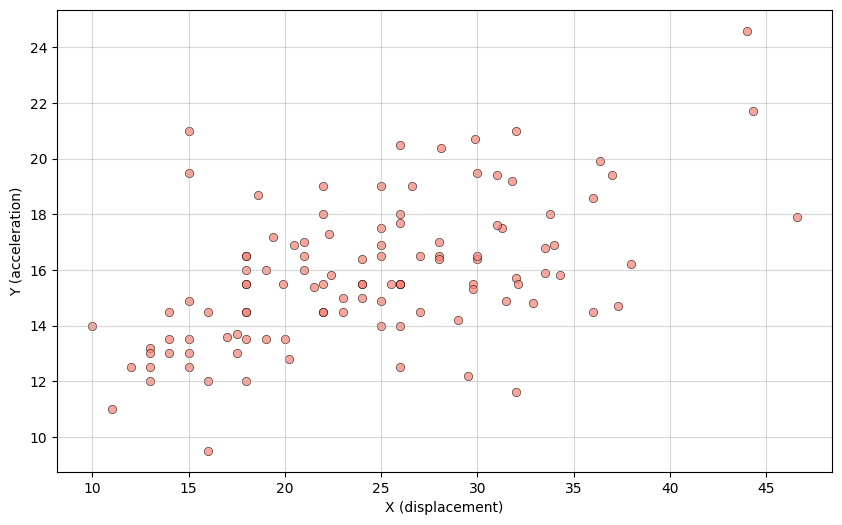

In [2]:
# Извлечение выборки из файла
df_file = pd.read_csv("auto-mpg.txt", sep='\\s+', header=None, na_values='?')
sample_df = df_file.sample(n=110, random_state=24)
df = pd.DataFrame({'displacement': sample_df[0], 'acceleration': sample_df[5]}).reset_index(drop=True)

# Определение переменных X и Y
x_values = df['displacement'].values
y_values = df['acceleration'].values

# Отображение двумерной выборки на графике
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, color='salmon', edgecolors='black', linewidth=0.5)
plt.xlabel('X (displacement)')
plt.ylabel('Y (acceleration)')
plt.grid(alpha=0.5)
plt.show()

## Задание 2

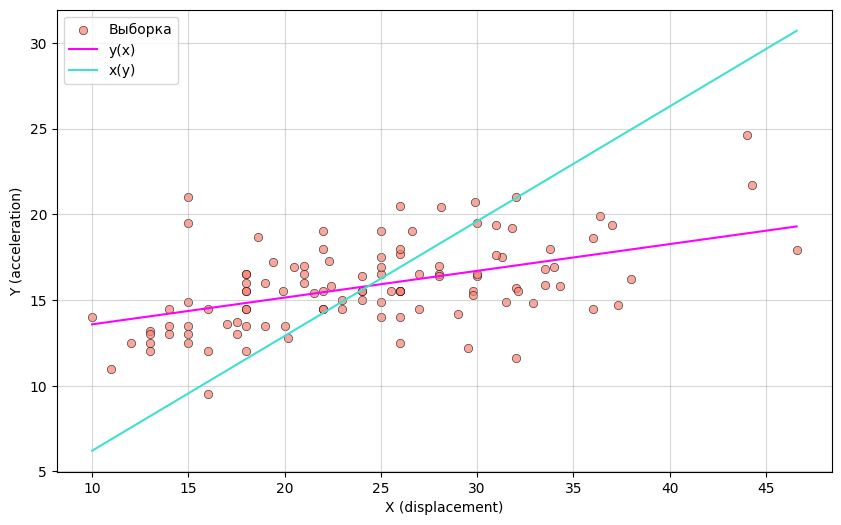

In [3]:
# Параметры, вычисленные в предыдущих практических работах
x_v = 24.36
y_v = 15.82
s_x = 7.9836
s_y = 2.5797
r_xy = 0.4828

# Вычисление коэффициентов регрессии
a_yx = r_xy * (s_y / s_x)
b_yx = y_v - a_yx * x_v

a_xy = r_xy * (s_x / s_y)
b_xy = x_v - a_xy * y_v

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, color='salmon', edgecolors='black', linewidth=0.5, label='Выборка')

x_linear = np.linspace(x_values.min(), x_values.max(), 110)
y_linear = a_yx * x_linear + b_yx
plt.plot(x_linear, y_linear, 'fuchsia', linewidth=1.5, label=f'y(x)')

plt.plot(x_linear, (x_linear - b_xy) / a_xy, 'turquoise', linewidth=1.5, label=f'x(y)')

plt.xlabel('X (displacement)')
plt.ylabel('Y (acceleration)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

Фиолетовая прямая описывает зависимость $y(x)$ и строится так, чтобы минимизировать вертикальные отклонения точек от линии. Она показывает, что при увеличении $x$ значение $y$ растет, но это происходит довольно медленно.

Бирюзовая прямая соответствует зависимости $x(y)$ и минимизирует уже горизонтальные отклонения точек от линии. Поэтому она имеет гораздо больший наклон и заметно отличается от первой прямой.

Можно сделать вывод, что между величинами существует положительная линейная зависимость.

## Задание 3

In [4]:
# Корреляционная таблица
x_centers = [12.6, 17.8, 23.1, 28.3, 33.5, 38.8, 44.0]
y_centers = [10.6, 12.7, 14.9, 17.1, 19.2, 21.4, 23.5]

freq_matrix = np.array([
    [1, 1, 0, 0, 1, 0, 0],
    [10, 9, 0, 2, 0, 0, 0],
    [3, 6, 13, 8, 7, 1, 0],
    [0, 5, 10, 8, 5, 1, 1],
    [1, 1, 2, 2, 3, 2, 0],
    [1, 0, 0, 3, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 1]
])

n_x = freq_matrix.sum(axis=0)
n_y = freq_matrix.sum(axis=1)
N = freq_matrix.sum()

# Расчет средних y по группам x
y_group_means = []
for j in range(len(x_centers)):
    weighted_sum = 0
    for i in range(len(y_centers)):
        weighted_sum += freq_matrix[i, j] * y_centers[i]
    mean = round(weighted_sum / n_x[j], 2)
    y_group_means.append(mean)

# Расчет средних x по группам y
x_group_means = []
for i in range(len(y_centers)):
    weighted_sum = 0
    for j in range(len(x_centers)):
        weighted_sum += freq_matrix[i, j] * x_centers[j]
    mean = round(weighted_sum / n_y[i], 2)
    x_group_means.append(mean)

# Создание таблицы с групповыми средними
table_data = []
header_row = ["Y \\ X"] + x_centers + ["n_yi"] + ["x̄_yi"]
table_data.append(header_row)

for i, y_center in enumerate(y_centers):
    row = [y_center] + freq_matrix[i].tolist() + [n_y[i]] + [x_group_means[i]]
    table_data.append(row)

sum_row = ["n_xj"] + n_x.tolist() + [N]
table_data.append(sum_row)

mean_y_row = ["ȳ_xj"] + y_group_means + [""] + [""]
table_data.append(mean_y_row)

print(tabulate(table_data, tablefmt='grid'))

+-------+-------+------+-------+------+-------+------+-------+------+-------+
| Y \ X | 12.6  | 17.8 | 23.1  | 28.3 | 33.5  | 38.8 | 44    | n_yi | x̄_yi  |
+-------+-------+------+-------+------+-------+------+-------+------+-------+
| 10.6  |  1    |  1   |  0    |  0   |  1    |  0   |  0    | 3    | 21.3  |
+-------+-------+------+-------+------+-------+------+-------+------+-------+
| 12.7  | 10    |  9   |  0    |  2   |  0    |  0   |  0    | 21   | 16.32 |
+-------+-------+------+-------+------+-------+------+-------+------+-------+
| 14.9  |  3    |  6   | 13    |  8   |  7    |  1   |  0    | 38   | 24.86 |
+-------+-------+------+-------+------+-------+------+-------+------+-------+
| 17.1  |  0    |  5   | 10    |  8   |  5    |  1   |  1    | 30   | 26.56 |
+-------+-------+------+-------+------+-------+------+-------+------+-------+
| 19.2  |  1    |  1   |  2    |  2   |  3    |  2   |  0    | 11   | 28.3  |
+-------+-------+------+-------+------+-------+------+-------+-

In [5]:
# Вычисление общих средних
x_v_general = round(np.sum(n_x * x_centers) / N, 2)
y_v_general = round(np.sum(n_y * y_centers) / N, 2)

# Вычисление общих дисперсий
D_x_general = round(np.sum(n_x * (x_centers - x_v_general) ** 2) / N, 2)
D_y_general = round(np.sum(n_y * (y_centers - y_v_general) ** 2) / N, 2)

# Вычисление межгрупповых дисперсий
D_x_intergroup = round(np.sum(n_y * (x_group_means - x_v_general) ** 2) / N, 2)
D_y_intergroup = round(np.sum(n_x * (y_group_means - y_v_general) ** 2) / N, 2)

# Вычисление корреляционных отношений
eta_yx = round(np.sqrt(D_y_intergroup / D_y_general), 4)
eta_xy = round(np.sqrt(D_x_intergroup / D_x_general), 4)

# Проверка неравенств
if eta_yx >= abs(r_xy) and eta_xy >= abs(r_xy):
    print("Неравенства выполняются")
    print(f"η_yx = {eta_yx} ≥ |r_xy| = {abs(r_xy)}")
    print(f"η_xy = {eta_xy} ≥ |r_xy| = {abs(r_xy)}")
else:
    print("Неравенства не выполняются")

Неравенства выполняются
η_yx = 0.5275 ≥ |r_xy| = 0.4828
η_xy = 0.5664 ≥ |r_xy| = 0.4828


## Задание 4

In [6]:
# Формирование данных для таблицы
table_data = []
for j in range(len(x_centers)):
    x = x_centers[j]
    n = n_x[j]
    y_mean = y_group_means[j]
    row = [x, n, y_mean, n * x, n * x**2, n * x**3, n * x**4, n * y_mean, n * x * y_mean, n * x**2 * y_mean]
    table_data.append(row)

# Суммирование
sum_nx = sum(n_x[j] * x_centers[j] for j in range(len(x_centers)))
sum_nx2 = sum(n_x[j] * x_centers[j] ** 2 for j in range(len(x_centers)))
sum_nx3 = sum(n_x[j] * x_centers[j] ** 3 for j in range(len(x_centers)))
sum_nx4 = sum(n_x[j] * x_centers[j] ** 4 for j in range(len(x_centers)))
sum_nxy = sum(n_x[j] * x_centers[j] * y_group_means[j] for j in range(len(x_centers)))
sum_nx2y = sum(n_x[j] * x_centers[j] ** 2 * y_group_means[j] for j in range(len(x_centers)))
sum_ny = sum(n_x[j] * y_group_means[j] for j in range(len(x_centers)))

table_data.append(["Σ", N, "", sum_nx, sum_nx2, sum_nx3, sum_nx4, sum_ny, sum_nxy, sum_nx2y])

headers = ["x", "n_x", "ȳ_x", "n·x", "n·x²", "n·x³", "n·x⁴", "n·ȳ", "n·ȳ·x", "n·ȳ·x²"]
print(tabulate(table_data, headers=headers, tablefmt='grid', floatfmt=".2f"))

# Решение системы нормальных уравнений для параболической регрессии
A = np.array([
    [sum_nx4, sum_nx3, sum_nx2],
    [sum_nx3, sum_nx2, sum_nx],
    [sum_nx2, sum_nx, N]])
B = np.array([sum_nx2y, sum_nxy, sum_ny])

a, b, c = np.linalg.solve(A, B)

+------+--------+-------+---------+----------+------------+-------------+---------+----------+------------+
| x    |    n_x | ȳ_x   |     n·x |     n·x² |       n·x³ |        n·x⁴ |     n·ȳ |    n·ȳ·x |     n·ȳ·x² |
+======+========+=======+=========+==========+============+=============+=========+==========+============+
| 12.6 |  16.00 | 13.93 |  201.60 |  2540.16 |   32006.02 |   403275.80 |  222.88 |  2808.29 |   35384.43 |
+------+--------+-------+---------+----------+------------+-------------+---------+----------+------------+
| 17.8 |  22.00 | 14.5  |  391.60 |  6970.48 |  124074.54 |  2208526.88 |  319.00 |  5678.20 |  101071.96 |
+------+--------+-------+---------+----------+------------+-------------+---------+----------+------------+
| 23.1 |  25.00 | 16.12 |  577.50 | 13340.25 |  308159.78 |  7118490.80 |  403.00 |  9309.30 |  215044.83 |
+------+--------+-------+---------+----------+------------+-------------+---------+----------+------------+
| 28.3 |  23.00 | 16.7  |  6

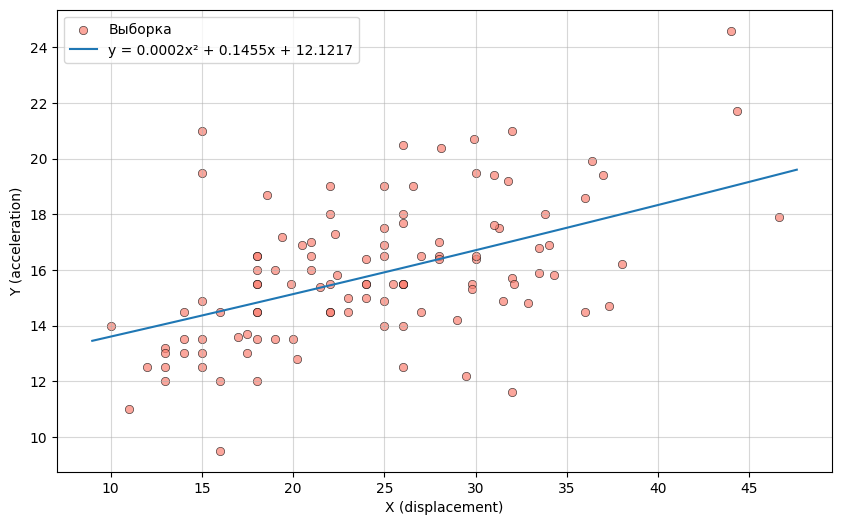

In [7]:
# Построение корреляционной кривой для параболической регрессии
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, color='salmon', edgecolors='black', linewidth=0.5, label='Выборка')

x_parabolic = np.linspace(min(x_values) - 1, max(x_values) + 1, 110)
y_parabolic = a * x_parabolic**2 + b * x_parabolic + c
plt.plot(x_parabolic, y_parabolic, linewidth=1.5, label=f'y = {a:.4f}x² + {b:.4f}x + {c:.4f}')

plt.xlabel('X (displacement)')
plt.ylabel('Y (acceleration)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

Параболическая кривая имеет маленький коэффициент при $x^2$, поэтому почти не отличается от прямой. То есть нелинейность в данных выражена слабо и практически не влияет на характер зависимости. По графику видно, что при увеличении $x$ значение $y$ возрастает, что подтверждает наличие положительной зависимости между переменными.

## Задание 5

Дробно-рациональная функция имеет вид:

$y = \frac{x}{\beta_0 + \beta_1 x}$

Для применения МНК выполним преобразование, обратив обе части уравнения:

$\frac{1}{y} = \frac{\beta_0 + \beta_1 x}{x} = \frac{\beta_0}{x} + \beta_1$

Введем новые переменные:

$Y = \frac{1}{y}, \quad X = \frac{1}{x}$

Тогда функция примет линейный вид:

$Y = \beta_1 + \beta_0 X$


Система нормальных уравнений для линейной функции:

$\begin{cases}
N \beta_1 + \beta_0 \displaystyle\sum_{i=1}^{m} X_i = \displaystyle\sum_{i=1}^{m} Y_i \\
\beta_1 \displaystyle\sum_{i=1}^{m} X_i + \beta_0 \displaystyle\sum_{i=1}^{m} X_i^2 = \displaystyle\sum_{i=1}^{m} X_i Y_i
\end{cases}$

In [8]:
# Формирование данных для таблицы
table_data = []
for j in range(len(x_centers)):
    x = x_centers[j]
    n = n_x[j]
    y_mean = y_group_means[j]
    X = 1 / x
    Y = 1 / y_mean
    row = [x, n, f"{y_mean:.2f}", f"{X:.4f}", f"{Y:.4f}", f"{n * X:.4f}", f"{n * Y:.4f}", f"{n * X**2:.4f}", f"{n * X * Y:.4f}"]
    table_data.append(row)

# Суммирование
sum_nX = sum(n_x[j] * (1 / x_centers[j]) for j in range(len(x_centers)))
sum_nY = sum(n_x[j] * (1 / y_group_means[j]) for j in range(len(x_centers)))
sum_nX2 = sum(n_x[j] * (1 / x_centers[j])**2 for j in range(len(x_centers)))
sum_nXY = sum(n_x[j] * (1 / x_centers[j]) * (1 / y_group_means[j]) for j in range(len(x_centers)))

table_data.append(["Σ", N, "", "", "", f"{sum_nX:.4f}", f"{sum_nY:.4f}", f"{sum_nX2:.4f}", f"{sum_nXY:.4f}"])

headers = ["x", "n_x", "ȳ_x", "X = 1/x", "Y = 1/ȳ", "n·X", "n·Y", "n·X²", "n·X·Y"]
print(tabulate(table_data, headers=headers, tablefmt='grid'))

# Решение системы
A = np.array([
    [N, sum_nX],
    [sum_nX, sum_nX2]])
B = np.array([sum_nY, sum_nXY])

beta1, beta0 = np.linalg.solve(A, B)

+------+-------+-------+-----------+-----------+--------+--------+--------+---------+
| x    |   n_x | ȳ_x   | X = 1/x   | Y = 1/ȳ   |    n·X |    n·Y |   n·X² |   n·X·Y |
+======+=======+=======+===========+===========+========+========+========+=========+
| 12.6 |    16 | 13.93 | 0.0794    | 0.0718    | 1.2698 | 1.1486 | 0.1008 |  0.0912 |
+------+-------+-------+-----------+-----------+--------+--------+--------+---------+
| 17.8 |    22 | 14.50 | 0.0562    | 0.0690    | 1.236  | 1.5172 | 0.0694 |  0.0852 |
+------+-------+-------+-----------+-----------+--------+--------+--------+---------+
| 23.1 |    25 | 16.12 | 0.0433    | 0.0620    | 1.0823 | 1.5509 | 0.0469 |  0.0671 |
+------+-------+-------+-----------+-----------+--------+--------+--------+---------+
| 28.3 |    23 | 16.70 | 0.0353    | 0.0599    | 0.8127 | 1.3772 | 0.0287 |  0.0487 |
+------+-------+-------+-----------+-----------+--------+--------+--------+---------+
| 33.5 |    17 | 16.44 | 0.0299    | 0.0608    | 0.507

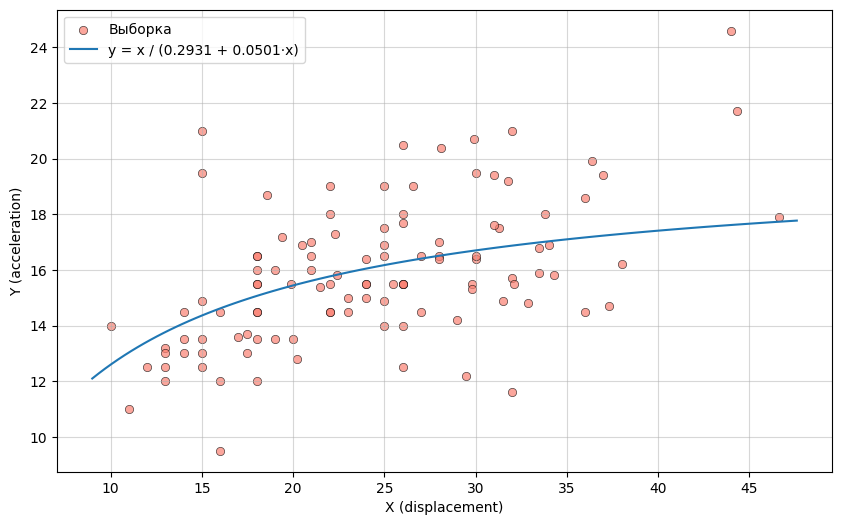

In [9]:
# Построение корреляционной кривой для дробно-рациональной регрессии
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, color='salmon', edgecolors='black', linewidth=0.5, label='Выборка')

x_frac = np.linspace(min(x_values) - 1, max(x_values) + 1, 110)
y_frac = x_frac / (beta0 + beta1 * x_frac)
plt.plot(x_frac, y_frac, linewidth=1.5, label=f'y = x / ({beta0:.4f} + {beta1:.4f}·x)')

plt.xlabel('X (displacement)')
plt.ylabel('Y (acceleration)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

По графику видно, что с ростом $x$ значения $y$ увеличиваются. Однако зависимость не является линейной, так как при малых значениях $x$ рост более интенсивный, чем при больших значениях.

Несмотря на наличие разброса экспериментальных точек относительно теоретической кривой, полученная функция хорошо отражает общий характер изменения признака. Это позволяет сделать вывод о том, что между переменными существует умеренная нелинейная зависимость, достаточно точно отражаемая дробно-рациональной функцией.

## Задание 6

In [12]:
# Вычисление показателей качества для линейной среднеквадратической регрессии
SS_tot = np.sum((y_values - y_mean) ** 2)
SS_res_lin = np.sum((y_values - y_linear) ** 2)
R2_lin = 1 - SS_res_lin / SS_tot
S_eps_lin = np.sqrt(SS_res_lin / N)
A_lin = np.mean(np.abs((y_values - y_linear) / y_values)) * 100

print(f"Показатели качества для линейной среднеквадратической регрессии:")
print(f"R² = {R2_lin:.4f}")
print(f"S_ε = {S_eps_lin:.4f}")
print(f"A = {A_lin:.2f}%\n")

# Вычисление показателей качества для параболической регрессии
SS_res_par = np.sum((y_values - y_parabolic) ** 2)
R2_par = 1 - SS_res_par / SS_tot
S_eps_par = np.sqrt(SS_res_par / N)
A_par = np.mean(np.abs((y_values - y_parabolic) / y_values)) * 100

print(f"Показатели качества для параболической регрессии:")
print(f"R² = {R2_par:.4f}")
print(f"S_ε = {S_eps_par:.4f}")
print(f"A = {A_par:.2f}%\n")

# Вычисление показателей качества для дробно-рациональной регрессии
SS_res_frac = np.sum((y_values - y_frac) ** 2)
R2_frac = 1 - SS_res_frac / SS_tot
S_eps_frac = np.sqrt(SS_res_frac / N)
A_frac = np.mean(np.abs((y_values - y_frac) / y_values)) * 100

print(f"Показатели качества для дробно-рациональной регрессии:")
print(f"R² = {R2_frac:.4f}")
print(f"S_ε = {S_eps_frac:.4f}")
print(f"A = {A_frac:.2f}%")

Показатели качества для линейной среднеквадратической регрессии:
R² = 0.6658
S_ε = 3.1555
A = 16.61%

Показатели качества для параболической регрессии:
R² = 0.6488
S_ε = 3.2346
A = 17.03%

Показатели качества для дробно-рациональной регрессии:
R² = 0.6889
S_ε = 3.0446
A = 15.96%


Наибольший коэффициент детерминации достигается для дробно-рациональной модели, что означает, что данная регрессия объясняет почти 69% вариации зависимой переменной. Самое низкое значение у параболической модели, что говорит о ее наименьшей точночти описания данных среди рассмотренных.

По средней квадратической ошибке наилучший результат также демонстрирует дробно-рациональная модель, тогда как наибольшая ошибка наблюдается у параболической регрессии. Аналогично и со средней ошибкой аппроксимации: минимальное значение у дробно-рациональной модели, максимальное — у параболической.

Таким образом, дробно-рациональная регрессия является лучшей моделью, превосходя линейную и параболическую по всем трем критериям качества. Также показатели качества всех моделей не достигают высоких значений, что объясняется значительным разбросом эмпирических данных относительно построенных кривых.

## Выводы

В ходе выполнения практической работы был проведен регрессионный анализ двумерной выборки, включающий построение уравнений выборочных прямых среднеквадратической регрессии, вычисление корреляционных отношений и построение нелинейных регрессионных моделей.

Графический анализ выборочных прямых среднеквадратической регрессии показал наличие положительной линейной зависимости между исследуемыми признаками.

Далее была составлена корреляционная таблица и рассчитаны корреляционные отношения $\eta_{yx}$ и $\eta_{xy}$. Проверка неравенств $\eta_{yx} \ge |r_{xy}|$ и $\eta_{xy} \ge |r_{xy}|$ подтвердила, что корреляционное отношение всегда не меньше модуля коэффициента корреляции.

Графический анализ показал, что параболическая регрессия практически не отличается от линейной, что говорит о слабо выраженной нелинейности, тогда как дробно-рациональная модель демонстрирует замедляющийся рост при увеличении значения $x$.

Сравнительный анализ показателей качества моделей позволил выявить, что дробно-рациональная регрессия превосходит линейную и параболическую по всем критериям (теоретическому коэффициенту детерминации, средней квадратической ошибке, средней ошибке аппроксимации), однако качество всех моделей нельзя признать высоким из-за значительного разброса эмпирических данных.